In [1]:
import mlflow
import os
import pandas as pd


In [ ]:
MLFLOW_SERVER_IP = "192.168.1.103"
MLFLOW_SERVER_IP = "localhost"
# MLflow
os.environ["MLFLOW_TRACKING_URI"] = f"http://{MLFLOW_SERVER_IP}:5000"

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
# MinIO
os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = f"http://{MLFLOW_SERVER_IP}:9000"

def get_exp_trials(experiment_name, return_artifacts = True, timeout=10):
    """
    Get all trials (runs) from a specific MLFlow experiment.
    
    Args:
        experiment_name (str): Name of the MLflow experiment
        timeout (int): Timeout in seconds for operations (default: 10)
        
    Returns:
        pd.DataFrame: DataFrame containing all runs with their metrics, parameters, and metadata
        None: If experiment not found or connection fails
    """
    tracking_uri = os.environ.get("MLFLOW_TRACKING_URI")
    print(f"Testing connection to MLflow server: {tracking_uri}")
    
    # Test if server is reachable
    try:
        response = requests.get(tracking_uri, timeout=5)
        print(f"✓ MLflow server is reachable (status: {response.status_code})")
    except requests.exceptions.Timeout:
        print("✗ Connection timed out. Server might be down or unreachable.")
        return None
    except requests.exceptions.ConnectionError:
        print("✗ Connection error. Check if server is running and network is available.")
        return None
    except Exception as e:
        print(f"✗ Error connecting to server: {e}")
        return None
    
    # Set timeout for MLflow operations
    os.environ["MLFLOW_HTTP_REQUEST_TIMEOUT"] = str(timeout)
    
    print(f"Creating MLflow client...")
    client = mlflow.tracking.MlflowClient()
    
    print(f"Getting experiment: '{experiment_name}'...")
    try:
        # Get the experiment by name
        experiment = client.get_experiment_by_name(experiment_name)
        print(f"✓ Found experiment: {experiment.name if experiment else None}")
    except Exception as e:
        print(f"✗ Error getting experiment: {e}")
        return None
    
    if not experiment:
        print(f"✗ MLflow experiment '{experiment_name}' not found.")
        return None
    
    # Search all runs in the experiment
    print(f"Searching for runs in experiment...")
    try:
        runs = client.search_runs(
            experiment_ids=[experiment.experiment_id],
            order_by=["start_time DESC"]  # Most recent first
        )
        print(f"✓ Found {len(runs)} runs")
    except Exception as e:
        print(f"✗ Error searching runs: {e}")
        return None
    
    if not runs:
        print(f"⚠ No runs found in experiment '{experiment_name}'")
        return pd.DataFrame()

    # Convert runs to dicts
    print(f"Converting {len(runs)} runs to DataFrame...")
    runs_data = []
    artifacts = {}
    for run in runs:
        run_dict = {
            'run_id': run.info.run_id,
            'run_name': run.info.run_name,
            'status': run.info.status,
            'start_time': pd.to_datetime(run.info.start_time, unit='ms'),
            'end_time': pd.to_datetime(run.info.end_time, unit='ms') if run.info.end_time else None,
        }
        
        # Add all metrics, params, and tags
        run_dict.update({f'metric_{k}': v for k, v in run.data.metrics.items()})
        #run_dict.update({f'param_{k}': v for k, v in run.data.params.items()})
        #run_dict.update({f'tag_{k}': v for k, v in run.data.tags.items()})

        print(run.info.artifact_uri)

        if return_artifacts:
            artifacts[run_dict['run_name']] = None
        
        runs_data.append(run_dict)
    
    df = pd.DataFrame(runs_data)
    print(f"✓ Successfully created DataFrame with {len(df)} rows and {len(df.columns)} columns")

    if return_artifacts:
        return df, artifacts
    return df


In [3]:
# Get all trials from an experiment
exp_name = '15min_next2weeks2'

# Call with timeout parameter (default is 10 seconds, increase if needed)
trials_df, artifacts = get_exp_trials(exp_name, timeout=15)

# Display the results
if trials_df is not None and not trials_df.empty:
    print(f"\n📊 Retrieved {len(trials_df)} trials")
    display(trials_df.head())

Testing connection to MLflow server: http://localhost:5000
✓ MLflow server is reachable (status: 200)
Creating MLflow client...
Getting experiment: '15min_next2weeks2'...
✓ Found experiment: 15min_next2weeks2
Searching for runs in experiment...
✓ Found 105 runs
Converting 105 runs to DataFrame...
s3://mlflow/22/764be86c09f647aea0d13614310dded5/artifacts
s3://mlflow/22/0e48f7d92fb642ea96b10145c29b5dba/artifacts
s3://mlflow/22/074baed6c1464d2dacc6b78d62698140/artifacts
s3://mlflow/22/025d81f402cb47729b56d2649076024f/artifacts
s3://mlflow/22/b1d33103033643d3b02506891bddfe8a/artifacts
s3://mlflow/22/8c95d537836f40378b020cf5cb5596f4/artifacts
s3://mlflow/22/3ad04d0946254e1590375d2cab11420b/artifacts
s3://mlflow/22/ea57c4db7ac54a719216ebd104f7d47d/artifacts
s3://mlflow/22/3d1c422115b3466d90510faa7af6d589/artifacts
s3://mlflow/22/a0c0b32e13e4427dae34ba916a5a2616/artifacts
s3://mlflow/22/430d98e117044792b0b137625747923d/artifacts
s3://mlflow/22/9576b608e6a142f6b0aa883949dadeca/artifacts
s3://m

,run_id,run_name,status,start_time,end_time,metric_test_mda_metric,metric_test_mse_loss,metric_train_mse_loss,metric_vali_mda_metric,metric_vali_mse_loss,...,metric_RMSE_15,metric_RMSE_16,metric_RMSE_17,metric_RMSE_18,metric_RMSE_19,metric_RMSE_20,metric_RMSE_21,metric_RMSE_22,metric_RMSE_23,metric_RMSE_24
0,764be86c09f647aea0d13614310dded5,trial_15c00f1a_min_full_dates_2021-12-29_2022-...,FINISHED,2025-11-20 20:06:03.623,2025-11-20 20:14:53.869,0.494371,0.000016,0.000009,0.496506,0.000014,...,0.004167,0.004168,0.004166,0.004165,0.004169,0.004165,0.004165,0.004173,0.004161,0.004169
1,0e48f7d92fb642ea96b10145c29b5dba,trial_c742c71b_min_full_dates_2021-12-22_2022-...,FINISHED,2025-11-20 19:54:45.363,2025-11-20 20:05:35.549,0.500582,0.000008,0.000007,0.506793,0.000010,...,0.003060,0.003058,0.003060,0.003060,0.003067,0.003060,0.003060,0.003058,0.003057,0.003057
2,074baed6c1464d2dacc6b78d62698140,trial_2527f8fd_min_full_dates_2021-12-15_2021-...,FINISHED,2025-11-20 19:43:51.397,2025-11-20 19:54:16.541,0.502329,0.000008,0.000010,0.498059,0.000005,...,0.003421,0.003420,0.003420,0.003423,0.003423,0.003408,0.003407,0.003406,0.003406,0.003406
3,025d81f402cb47729b56d2649076024f,trial_382ed17d_min_full_dates_2021-12-08_2021-...,FINISHED,2025-11-20 19:32:33.976,2025-11-20 19:43:22.949,0.500000,0.000010,0.000015,0.494177,0.000013,...,0.002850,0.002854,0.002847,0.002849,0.002850,0.002847,0.002847,0.002848,0.002846,0.002847
4,b1d33103033643d3b02506891bddfe8a,trial_20e26f00_min_full_dates_2021-12-01_2021-...,FINISHED,2025-11-20 19:22:36.196,2025-11-20 19:32:05.726,0.498253,0.000015,0.000037,0.496506,0.000019,...,0.002904,0.002904,0.002902,0.002898,0.002899,0.002902,0.002901,0.002897,0.002896,0.002897


In [4]:
df = trials_df.copy()
df.head()

,run_id,run_name,status,start_time,end_time,metric_test_mda_metric,metric_test_mse_loss,metric_train_mse_loss,metric_vali_mda_metric,metric_vali_mse_loss,...,metric_RMSE_15,metric_RMSE_16,metric_RMSE_17,metric_RMSE_18,metric_RMSE_19,metric_RMSE_20,metric_RMSE_21,metric_RMSE_22,metric_RMSE_23,metric_RMSE_24
0,764be86c09f647aea0d13614310dded5,trial_15c00f1a_min_full_dates_2021-12-29_2022-...,FINISHED,2025-11-20 20:06:03.623,2025-11-20 20:14:53.869,0.494371,0.000016,0.000009,0.496506,0.000014,...,0.004167,0.004168,0.004166,0.004165,0.004169,0.004165,0.004165,0.004173,0.004161,0.004169
1,0e48f7d92fb642ea96b10145c29b5dba,trial_c742c71b_min_full_dates_2021-12-22_2022-...,FINISHED,2025-11-20 19:54:45.363,2025-11-20 20:05:35.549,0.500582,0.000008,0.000007,0.506793,0.000010,...,0.003060,0.003058,0.003060,0.003060,0.003067,0.003060,0.003060,0.003058,0.003057,0.003057
2,074baed6c1464d2dacc6b78d62698140,trial_2527f8fd_min_full_dates_2021-12-15_2021-...,FINISHED,2025-11-20 19:43:51.397,2025-11-20 19:54:16.541,0.502329,0.000008,0.000010,0.498059,0.000005,...,0.003421,0.003420,0.003420,0.003423,0.003423,0.003408,0.003407,0.003406,0.003406,0.003406
3,025d81f402cb47729b56d2649076024f,trial_382ed17d_min_full_dates_2021-12-08_2021-...,FINISHED,2025-11-20 19:32:33.976,2025-11-20 19:43:22.949,0.500000,0.000010,0.000015,0.494177,0.000013,...,0.002850,0.002854,0.002847,0.002849,0.002850,0.002847,0.002847,0.002848,0.002846,0.002847
4,b1d33103033643d3b02506891bddfe8a,trial_20e26f00_min_full_dates_2021-12-01_2021-...,FINISHED,2025-11-20 19:22:36.196,2025-11-20 19:32:05.726,0.498253,0.000015,0.000037,0.496506,0.000019,...,0.002904,0.002904,0.002902,0.002898,0.002899,0.002902,0.002901,0.002897,0.002896,0.002897


In [5]:
df.drop(columns=['run_id', 'status', 'start_time', 'end_time'], inplace=True)
df['start'] = df['run_name'].str.split('_').str[5]
df['end'] = df['run_name'].str.split('_').str[6]
df['start'] = pd.to_datetime(df['start'], format='%Y-%m-%d %H:%M:%S')
df['end'] = pd.to_datetime(df['end'], format='%Y-%m-%d %H:%M:%S')
df.head()


,run_name,metric_test_mda_metric,metric_test_mse_loss,metric_train_mse_loss,metric_vali_mda_metric,metric_vali_mse_loss,metric_inf_pred_1_mda,metric_inf_pred_2_mda,metric_inf_pred_3_mda,metric_inf_pred_4_mda,...,metric_RMSE_17,metric_RMSE_18,metric_RMSE_19,metric_RMSE_20,metric_RMSE_21,metric_RMSE_22,metric_RMSE_23,metric_RMSE_24,start,end
0,trial_15c00f1a_min_full_dates_2021-12-29_2022-...,0.494371,0.000016,0.000009,0.496506,0.000014,0.493924,0.504778,0.502609,0.503916,...,0.004166,0.004165,0.004169,0.004165,0.004165,0.004173,0.004161,0.004169,2021-12-29,2022-01-12
1,trial_c742c71b_min_full_dates_2021-12-22_2022-...,0.500582,0.000008,0.000007,0.506793,0.000010,0.539931,0.550825,0.549565,0.553525,...,0.003060,0.003060,0.003067,0.003060,0.003060,0.003058,0.003057,0.003057,2021-12-22,2022-01-05
2,trial_2527f8fd_min_full_dates_2021-12-15_2021-...,0.502329,0.000008,0.000010,0.498059,0.000005,0.500868,0.523023,0.514783,0.512620,...,0.003420,0.003423,0.003423,0.003408,0.003407,0.003406,0.003406,0.003406,2021-12-15,2021-12-29
3,trial_382ed17d_min_full_dates_2021-12-08_2021-...,0.500000,0.000010,0.000015,0.494177,0.000013,0.501736,0.531712,0.508696,0.514360,...,0.002847,0.002849,0.002850,0.002847,0.002847,0.002848,0.002846,0.002847,2021-12-08,2021-12-22
4,trial_20e26f00_min_full_dates_2021-12-01_2021-...,0.498253,0.000015,0.000037,0.496506,0.000019,0.506516,0.494783,0.501305,0.504355,...,0.002902,0.002898,0.002899,0.002902,0.002901,0.002897,0.002896,0.002897,2021-12-01,2021-12-15


In [6]:
for col in df.columns:
    if col.split("_")[0] == "param":
        df.drop(columns=[col], inplace=True)
    elif col.split("_")[0] == "metric" and col.split("_")[-1] == "mda":
        pred = col.split("_")[-2]
        df.rename(columns={col: f"mda_{pred}"}, inplace=True)
    elif col.split("_")[0] == "metric" and col.split("_")[-1] == "mse":
        pred = col.split("_")[-2]
        df.rename(columns={col: f"mse_{pred}"}, inplace=True)
    elif col.split("_")[0] == "metric" and col.split("_")[1].lower() == "rmse":
        pred = col.split("_")[-1]
        df.rename(columns={col: f"rmse_{pred}"}, inplace=True)
    elif col.split("_")[0] == "tag":
        df.drop(columns=[col], inplace=True)
    elif col.split("_")[0] == "metric":
        name = "_".join(col.split("_")[1:])
        df.rename(columns={col: name}, inplace=True)



df.head()

print(df.columns)
df.sort_values(by="start", ascending=True, inplace=True)

Index(['run_name', 'test_mda_metric', 'test_mse_loss', 'train_mse_loss',
       'vali_mda_metric', 'vali_mse_loss', 'mda_1', 'mda_2', 'mda_3', 'mda_4',
       'mda_5', 'mda_6', 'mda_7', 'mda_8', 'mda_9', 'mda_10', 'mda_11',
       'mda_12', 'mda_13', 'mda_14', 'mda_15', 'mda_16', 'mda_17', 'mda_18',
       'mda_19', 'mda_20', 'mda_21', 'mda_22', 'mda_23', 'mda_24', 'mse_1',
       'mse_2', 'mse_3', 'mse_4', 'mse_5', 'mse_6', 'mse_7', 'mse_8', 'mse_9',
       'mse_10', 'mse_11', 'mse_12', 'mse_13', 'mse_14', 'mse_15', 'mse_16',
       'mse_17', 'mse_18', 'mse_19', 'mse_20', 'mse_21', 'mse_22', 'mse_23',
       'mse_24', 'rmse_1', 'rmse_2', 'rmse_3', 'rmse_4', 'rmse_5', 'rmse_6',
       'rmse_7', 'rmse_8', 'rmse_9', 'rmse_10', 'rmse_11', 'rmse_12',
       'rmse_13', 'rmse_14', 'rmse_15', 'rmse_16', 'rmse_17', 'rmse_18',
       'rmse_19', 'rmse_20', 'rmse_21', 'rmse_22', 'rmse_23', 'rmse_24',
       'start', 'end'],
      dtype='object')


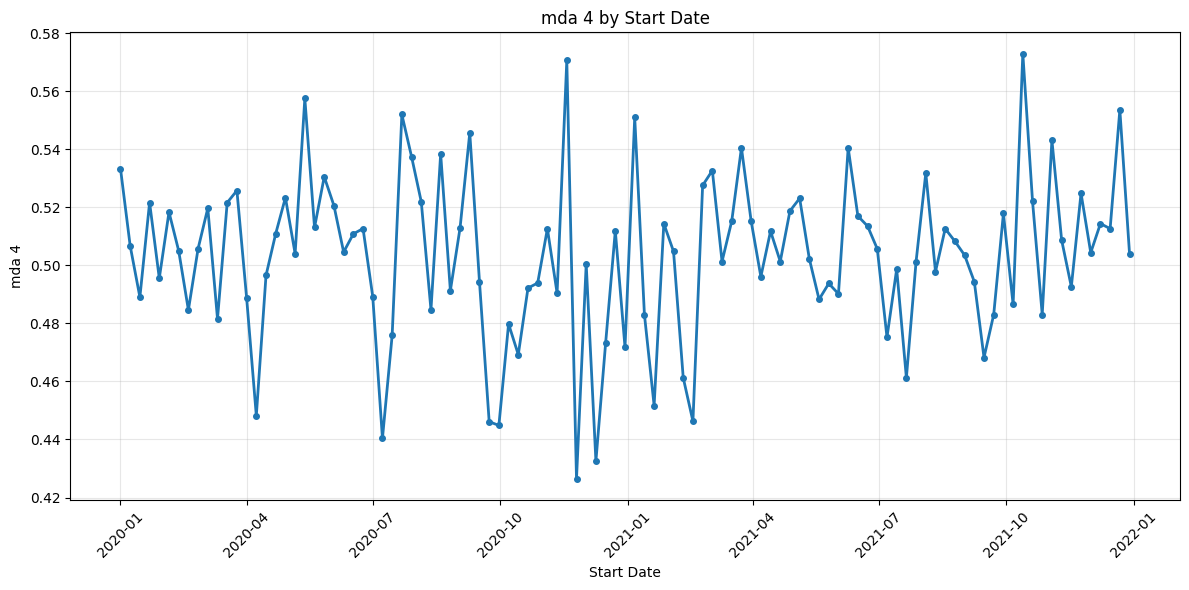

In [11]:
import matplotlib.pyplot as plt

pred = 4
metric = "mda"


plt.figure(figsize=(12, 6))
plt.plot(df['start'], df[f'{metric}_{pred}'], marker='o', linewidth=2, markersize=4)
plt.xlabel('Start Date')
plt.ylabel(f'{metric} {pred}')
plt.title(f'{metric} {pred} by Start Date')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
aggregated_metrics = df.drop(columns=['start', 'end','run_name']).mean()

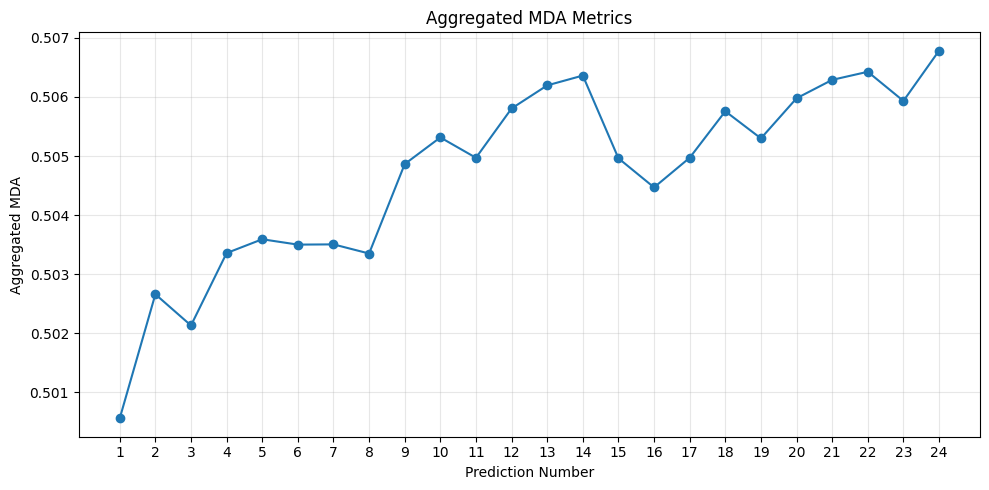

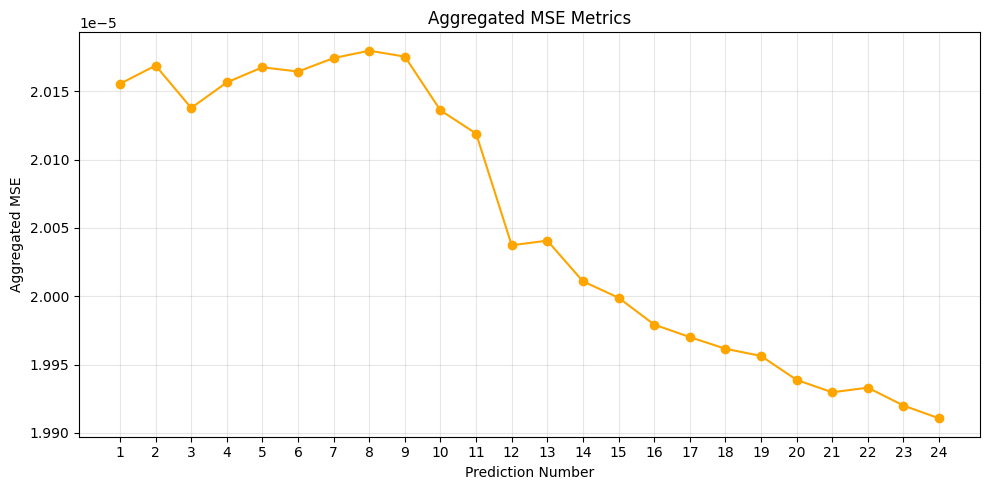

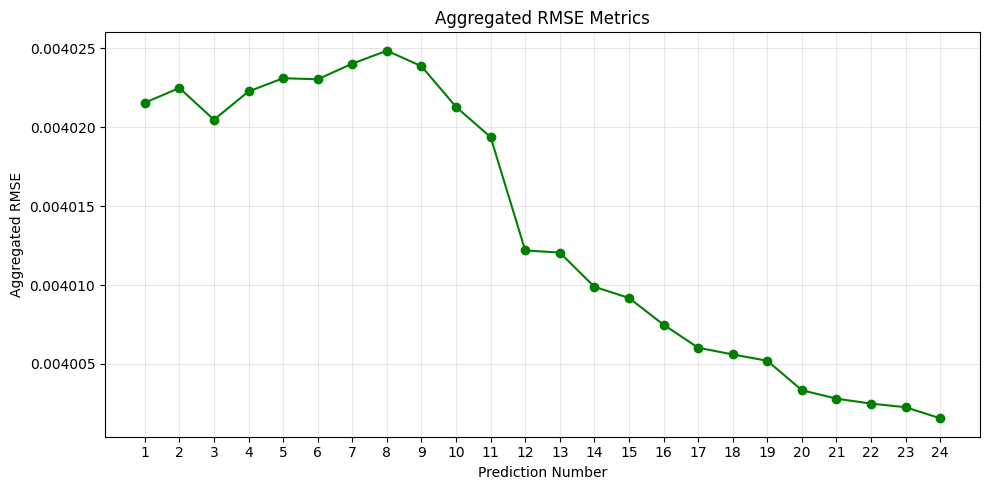

In [13]:
import re

# Get all metric names for mda, mse, and rmse
mda_cols = [col for col in aggregated_metrics.index if re.match(r"mda_\d+", col)]
mse_cols = [col for col in aggregated_metrics.index if re.match(r"mse_\d+", col)]
rmse_cols = [col for col in aggregated_metrics.index if re.match(r"rmse_\d+", col)]

# Extract numbers for sorting
def sort_key(col):
    return int(col.split('_')[1])

mda_cols_sorted = sorted(mda_cols, key=sort_key)
mse_cols_sorted = sorted(mse_cols, key=sort_key)
rmse_cols_sorted = sorted(rmse_cols, key=sort_key)

# Plot mda
plt.figure(figsize=(10, 5))
plt.plot(
    [int(col.split('_')[1]) for col in mda_cols_sorted],
    [aggregated_metrics[col] for col in mda_cols_sorted],
    marker='o', label='MDA'
)
plt.xlabel('Prediction Number')
plt.ylabel('Aggregated MDA')
plt.title('Aggregated MDA Metrics')
plt.grid(True, alpha=0.3)
plt.xticks([int(col.split('_')[1]) for col in mda_cols_sorted])
plt.tight_layout()
plt.show()

# Plot mse
plt.figure(figsize=(10, 5))
plt.plot(
    [int(col.split('_')[1]) for col in mse_cols_sorted],
    [aggregated_metrics[col] for col in mse_cols_sorted],
    marker='o', color='orange', label='MSE'
)
plt.xlabel('Prediction Number')
plt.ylabel('Aggregated MSE')
plt.title('Aggregated MSE Metrics')
plt.grid(True, alpha=0.3)
plt.xticks([int(col.split('_')[1]) for col in mse_cols_sorted])
plt.tight_layout()
plt.show()

# Plot rmse
plt.figure(figsize=(10, 5))
plt.plot(
    [int(col.split('_')[1]) for col in rmse_cols_sorted],
    [aggregated_metrics[col] for col in rmse_cols_sorted],
    marker='o', color='green', label='RMSE'
)
plt.xlabel('Prediction Number')
plt.ylabel('Aggregated RMSE')
plt.title('Aggregated RMSE Metrics')
plt.grid(True, alpha=0.3)
plt.xticks([int(col.split('_')[1]) for col in rmse_cols_sorted])
plt.tight_layout()
plt.show()
